In [2]:
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import warnings
import plotly.express as px
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [4]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    
    # Subset: apartments in Distrito Federal under $100,000
    mask_apt = df["property_type"] == "apartment"
    mask_ba = df["place_with_parent_names"].str.contains("Distrito Federal")
    mask_price = df["price_aprox_usd"] < 100_000
    df = df[mask_apt & mask_ba & mask_price]

    # Remove outliers: trim bottom and top 10% of surface_covered_in_m2
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Create separate lat and lon columns
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Create borough feature
    df["borough"] = df["place_with_parent_names"].str.split("|", expand=True)[1]
    df.drop(columns="place_with_parent_names", inplace=True)

    # Drop columns with more than 50% null values
    null_threshold = len(df) * 0.5
    df.drop(columns=[col for col in df.columns if df[col].isna().sum() > null_threshold], inplace=True)

    # Drop low- and high-cardinality categorical columns
    df.drop(columns=["operation", "property_type", "currency", "properati_url"], inplace=True)

    # Drop leakage columns
    df.drop(columns=["price", "price_aprox_local_currency", "price_per_m2"], inplace=True)

    # Drop multicollinearity columns
    df.drop(columns=["surface_total_in_m2", "rooms"], inplace=True, errors="ignore")

    return df
frame1 = wrangle("data/mexico-city-real-estate-1.csv")
frame1.head()

,price_aprox_usd,surface_covered_in_m2,lat,lon,borough
11,94022.66,57.0,23.634501,-102.552788,Benito Juárez
20,70880.12,56.0,19.402413,-99.095391,Iztacalco
21,68228.99,80.0,19.357820,-99.149406,Benito Juárez
22,24235.78,60.0,19.504985,-99.208557,Azcapotzalco
26,94140.20,50.0,19.354219,-99.126244,Coyoacán


<Axes: >

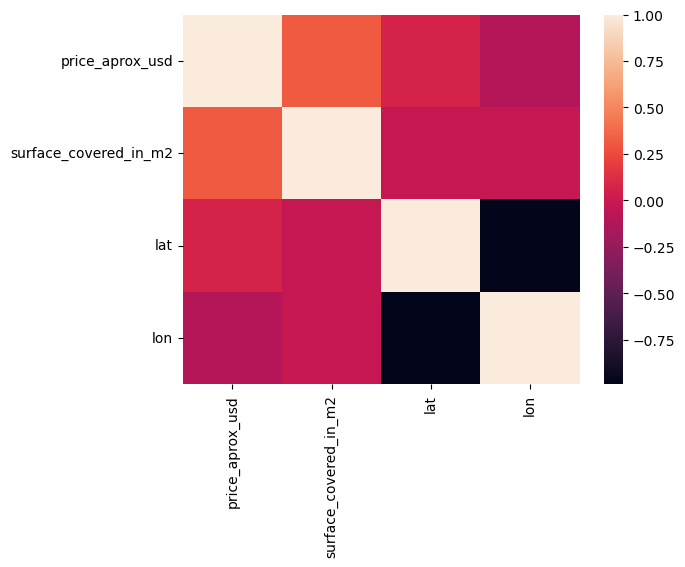

In [5]:
df = wrangle("data/mexico-city-real-estate-1.csv")
corr = df.select_dtypes("number").corr()
sns.heatmap(corr)

In [7]:
files = glob('data/mexico-city-real-estate-*.csv')

In [8]:
df = pd.concat([wrangle(file) for file in files], ignore_index=True)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5473 entries, 0 to 5472
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        5473 non-null   float64
 1   surface_covered_in_m2  5473 non-null   float64
 2   lat                    5149 non-null   float64
 3   lon                    5149 non-null   float64
 4   borough                5473 non-null   str    
dtypes: float64(4), str(1)
memory usage: 213.9 KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,borough
0,94022.66,57.0,23.634501,-102.552788,Benito Juárez
1,70880.12,56.0,19.402413,-99.095391,Iztacalco
2,68228.99,80.0,19.357820,-99.149406,Benito Juárez
3,24235.78,60.0,19.504985,-99.208557,Azcapotzalco
4,94140.20,50.0,19.354219,-99.126244,Coyoacán


## Explore

<div class="alert alert-info" role="alert">
  <strong>Slight Code Change</strong>

In the following task, you'll notice a small change in how plots are created compared to what you saw in the lessons.
While the lessons use the global matplotlib method like <code>plt.plot(...)</code>, in this task, you are expected to use the object-oriented (OOP) API instead.
This means creating your plots using <code>fig, ax = plt.subplots()</code> and then calling plotting methods on the <code>ax</code> object, such as <code>ax.plot(...)</code>, <code>ax.hist(...)</code>, or <code>ax.scatter(...)</code>.

If you're using pandas’ or seaborn’s built-in plotting methods (like <code>df.plot()</code> or <code>sns.lineplot()</code>), make sure to pass the <code>ax=ax</code> argument so that the plot is rendered on the correct axes.

This approach is considered best practice and will be used consistently across all graded tasks that involve matplotlib.
</div>


Text(0.5, 1.0, 'Distribution of Apartment Prices')

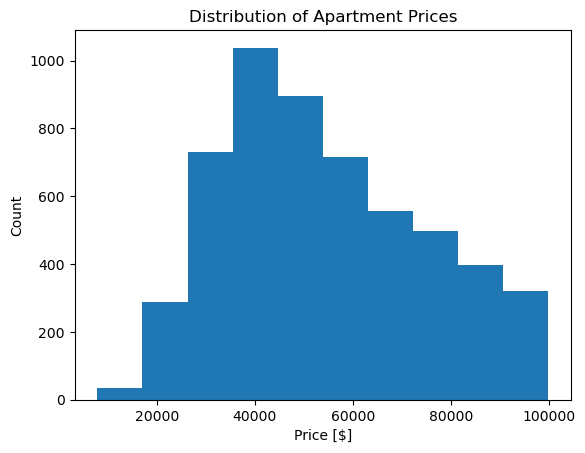

In [10]:
fig, ax = plt.subplots() 

# Plot the histogram on the axes object
ax.hist(df["price_aprox_usd"]) 

# Label axes using the axes 
ax.set_xlabel("Price [$]")
ax.set_ylabel("Count")


# Add title 
ax.set_title("Distribution of Apartment Prices")

Text(0.5, 1.0, 'Mexico City: Price vs. Area')

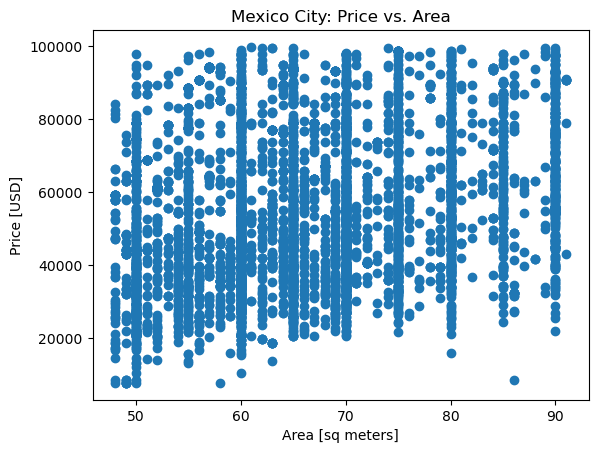

In [11]:
fig, ax = plt.subplots() 

# Create the scatter plot on the axes object
ax.scatter(x=df["surface_covered_in_m2"], y=df["price_aprox_usd"]) 

# Label axes 
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
# Add title
plt.title("Mexico City: Price vs. Area")

In [12]:
# Split data into feature matrix 'X_train' and target vector 'y_train'
target = "price_aprox_usd"  # <-- vector
features = ["surface_covered_in_m2", "lat", "lon", "borough"]  # <-- matrix
X_train = df[features]  # training data
y_train = df[target]

In [13]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
print("Mean apt price:", y_mean)
print("Baseline MAE:", baseline_mae)

Mean apt price: 54246.5314982642
Baseline MAE: 17239.939475888295


In [14]:
# Build Model
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    Ridge()
)
# fit ...
model.fit(X_train, y_train)


/home/munir/anaconda3/envs/wqu-projects/lib/python3.11/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('simpleimputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,['borough']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [15]:
X_test = pd.read_csv('data/mexico-city-test-features.csv')
print(X_test.info())
X_test.head()

<class 'pandas.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surface_covered_in_m2  1041 non-null   float64
 1   lat                    986 non-null    float64
 2   lon                    986 non-null    float64
 3   borough                1041 non-null   str    
dtypes: float64(3), str(1)
memory usage: 32.7 KB
None


,surface_covered_in_m2,lat,lon,borough
0,60.0,19.493185,-99.205755,Azcapotzalco
1,55.0,19.307247,-99.166700,Coyoacán
2,50.0,19.363469,-99.010141,Iztapalapa
3,60.0,19.474655,-99.189277,Azcapotzalco
4,74.0,19.394628,-99.143842,Benito Juárez


In [16]:
y_test_pred = pd.Series(model.predict(X_test))
y_test_pred.head()

0    53538.366480
1    53171.988369
2    34263.884179
3    53488.425607
4    68738.924884
dtype: float64

# Communicate Results

In [17]:
intercept = model.named_steps["ridge"].intercept_
coefficients = model.named_steps["ridge"].coef_
features = model.named_steps["onehotencoder"].get_feature_names()

feat_imp = pd.Series(coefficients, index=features).sort_values(key=abs)
feat_imp


surface_covered_in_m2               291.654156
borough_Cuauhtémoc                 -350.531990
borough_Iztacalco                   405.403127
lat                                 478.901375
borough_Xochimilco                  929.857400
borough_Miguel Hidalgo             1977.314718
borough_Azcapotzalco               2459.288646
lon                               -2492.221814
borough_Álvaro Obregón             3275.121061
borough_Coyoacán                   3737.561001
borough_Venustiano Carranza       -5609.918629
borough_La Magdalena Contreras    -5925.666450
borough_Gustavo A. Madero         -6637.429757
borough_Cuajimalpa de Morelos      9157.269123
borough_Tlalpan                   10319.429804
borough_Iztapalapa               -13349.017448
borough_Benito Juárez             13778.188880
borough_Tláhuac                  -14166.869486
dtype: float64

Text(0.5, 1.0, 'Feature Importance for Apartment Price')

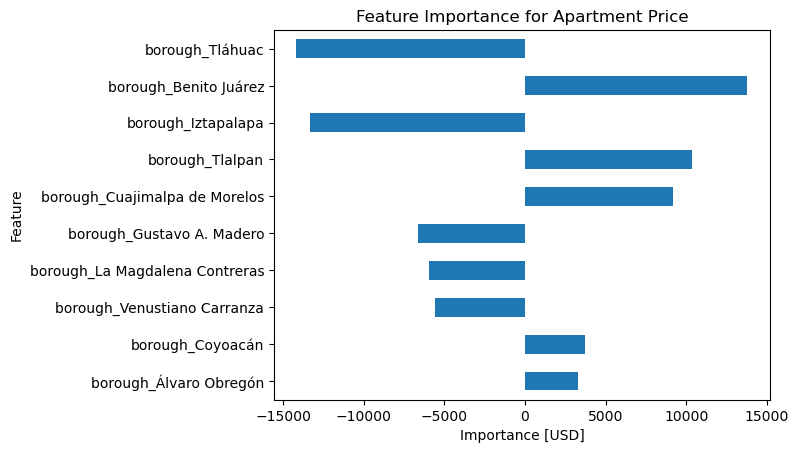

In [18]:
fig, ax = plt.subplots()

# Create the horizontal bar plot on the axes object
feat_imp.sort_values(key=abs).tail(10).plot(kind='barh')


plt.xlabel("Importance [USD]")
plt.ylabel("Feature")

# Add title
plt.title("Feature Importance for Apartment Price")